<a href="https://colab.research.google.com/github/Rohanrathod7/my-ds-labs/blob/main/07_Introduction_to_Statistics_in_Python/02_Random_Numbers_and_Probability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 2. Random Numbers and Probability

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import datetime as dt

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/07_Introduction_to_Statistics_in_Python/Dataset/food_consumption.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
food_consumption = pd.read_csv(url)

# Print the head of the homelessness data
print(food_consumption.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/WorldBank_GDP.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
gdp = pd.read_csv(url)

# Print the head of the homelessness data
print(gdp.head())

   Unnamed: 0    country food_category  consumption  co2_emission
0           1  Argentina          pork        10.51         37.20
1           2  Argentina       poultry        38.66         41.53
2           3  Argentina          beef        55.48       1712.00
3           4  Argentina     lamb_goat         1.56         54.63
4           5  Argentina          fish         4.36          6.96
    Country Name Country Code     Indicator Name  Year           GDP
0          China          CHN  GDP (current US$)  2010  6.087160e+12
1        Germany          DEU  GDP (current US$)  2010  3.417090e+12
2          Japan          JPN  GDP (current US$)  2010  5.700100e+12
3  United States          USA  GDP (current US$)  2010  1.499210e+13
4          China          CHN  GDP (current US$)  2011  7.551500e+12


----

### What are the chances?

**With or without replacement?**  
In the video, you learned about two different ways of taking samples: with replacement and without replacement. Although it isn't always easy to tell which best fits various situations, it's important to correctly identify this so that any probabilities you report are accurate. In this exercise, you'll put your new knowledge to the test and practice figuring this out.

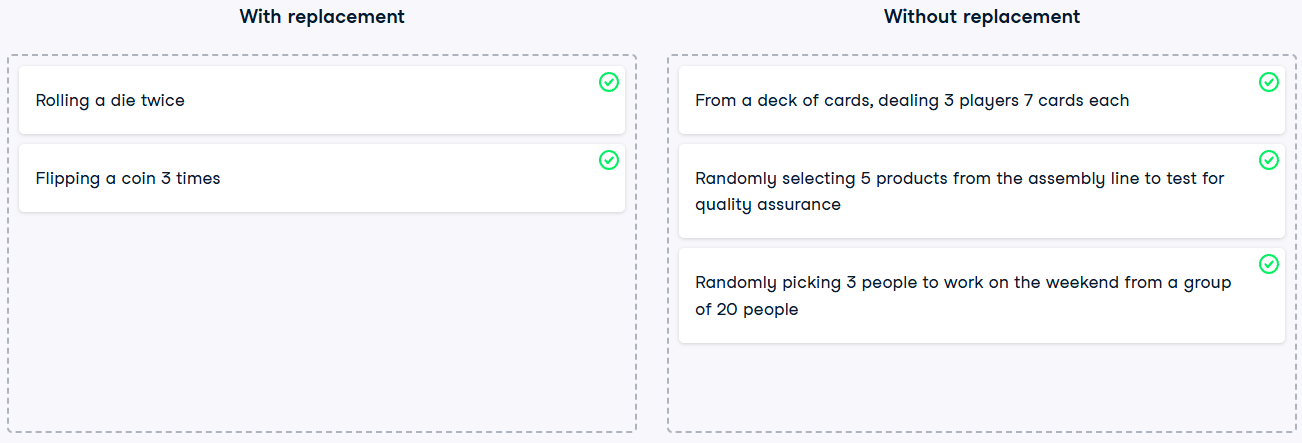

*Radical replacement judgment! Correctly identifying the type of sampling that needs to be used is key to calculating accurate probabilities. With replacement, everyone always has a 5% chance of working on the weekend. Without replacement, the second pick has a 4/19 chance, and the third pick has a 3/18 chance of working on the weekend.*

**Calculating probabilities**  
You're in charge of the sales team, and it's time for performance reviews, starting with Amir. As part of the review, you want to randomly select a few of the deals that he's worked on over the past year so that you can look at them more deeply. Before you start selecting deals, you'll first figure out what the chances are of selecting certain deals.

Recall that the probability of an event can be calculated by
 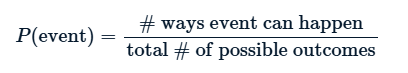

Both pandas as pd and numpy as np are loaded and amir_deals is available.

In [3]:
url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/07_Introduction_to_Statistics_in_Python/Dataset/amir_deals.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
amir_deals = pd.read_csv(url)

# Print the head of the homelessness data
print(amir_deals.head())

   Unnamed: 0    product   client status   amount  num_users
0           1  Product F  Current    Won  7389.52         19
1           2  Product C      New    Won  4493.01         43
2           3  Product B      New    Won  5738.09         87
3           4  Product I  Current    Won  2591.24         83
4           5  Product E  Current    Won  6622.97         17


In [4]:
# Count the deals for each product
counts = amir_deals['product'].value_counts()

# Calculate probability of picking a deal with each product
probs = counts / amir_deals.shape[0]
print(probs)

product
Product B    0.348315
Product D    0.224719
Product A    0.129213
Product C    0.084270
Product F    0.061798
Product H    0.044944
Product I    0.039326
Product E    0.028090
Product N    0.016854
Product G    0.011236
Product J    0.011236
Name: count, dtype: float64


**Sampling deals**  
In the previous exercise, you counted the deals Amir worked on. Now it's time to randomly pick five deals so that you can reach out to each customer and ask if they were satisfied with the service they received. You'll try doing this both with and without replacement.

Additionally, you want to make sure this is done randomly and that it can be reproduced in case you get asked how you chose the deals, so you'll need to set the random seed before sampling from the deals.

Both pandas as pd and numpy as np are loaded and amir_deals is available

**What type of sampling is better to use for this situation?**

-> *Without replacement*

In [5]:
# Set random seed
np.random.seed(24)

# Sample 5 deals without replacement
sample_without_replacement = amir_deals.sample(5, replace=False)
print(sample_without_replacement)

     Unnamed: 0    product   client status   amount  num_users
127         128  Product B  Current    Won  2070.25          7
148         149  Product D  Current    Won  3485.48         52
77           78  Product B  Current    Won  6252.30         27
104         105  Product D  Current    Won  4110.98         39
166         167  Product C      New   Lost  3779.86         11


In [6]:
# Set random seed
np.random.seed(24)

# Sample 5 deals with replacement
sample_with_replacement = amir_deals.sample(5, replace=True)
print(sample_with_replacement)

#  It's important to consider how you'll take a sample since there's no one-size-fits-all way to sample, and this can have an effect on your results.

     Unnamed: 0    product   client status   amount  num_users
162         163  Product D  Current    Won  6755.66         59
131         132  Product B  Current    Won  6872.29         25
87           88  Product C  Current    Won  3579.63          3
145         146  Product A  Current    Won  4682.94         63
145         146  Product A  Current    Won  4682.94         63


-----

### Discrete distributions

**Creating a probability distribution**  
A new restaurant opened a few months ago, and the restaurant's management wants to optimize its seating space based on the size of the groups that come most often. On one night, there are 10 groups of people waiting to be seated at the restaurant, but instead of being called in the order they arrived, they will be called randomly. In this exercise, you'll investigate the probability of groups of different sizes getting picked first. Data on each of the ten groups is contained in the restaurant_groups DataFrame.

Remember that expected value can be calculated by multiplying each possible outcome with its corresponding probability and taking the sum. The restaurant_groups data is available. pandas is loaded as pd, numpy is loaded as np, and matplotlib.pyplot is loaded as plt.

In [9]:
# Create the restaurant_groups DataFrame
restaurant_groups = pd.DataFrame({
    'group_id': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'],
    'group_size': [2, 4, 6, 2, 2, 2, 3, 2, 4, 2]
})


# Create probability distribution
size_dist = restaurant_groups['group_size'].value_counts(normalize=True).reset_index()
# Reset index and rename columns
size_dist.columns = ['group_size', 'prob']

# Expected value
expected_value = np.sum(size_dist['group_size'] * size_dist['prob'])
print(f'Expected value: {expected_value}')

# Subset groups of size 4 or more
groups_4_or_more = size_dist[size_dist['group_size'] >= 4]

# Sum the probabilities of groups_4_or_more
prob_4_or_more = groups_4_or_more['prob'].sum()
print(f'Probability of group size 4 or more: {prob_4_or_more}')

# Dexterous distribution utilization!
# You'll continue to build upon these skills since many statistical tests and methods use probability distributions as their foundation.

Expected value: 2.9000000000000004
Probability of group size 4 or more: 0.30000000000000004


----

### Continuous distributions

**Which distribution?**  
At this point, you've learned about the two different variants of the uniform distribution: the discrete uniform distribution, and the continuous uniform distribution. In this exercise, you'll decide which situations follow which distribution.

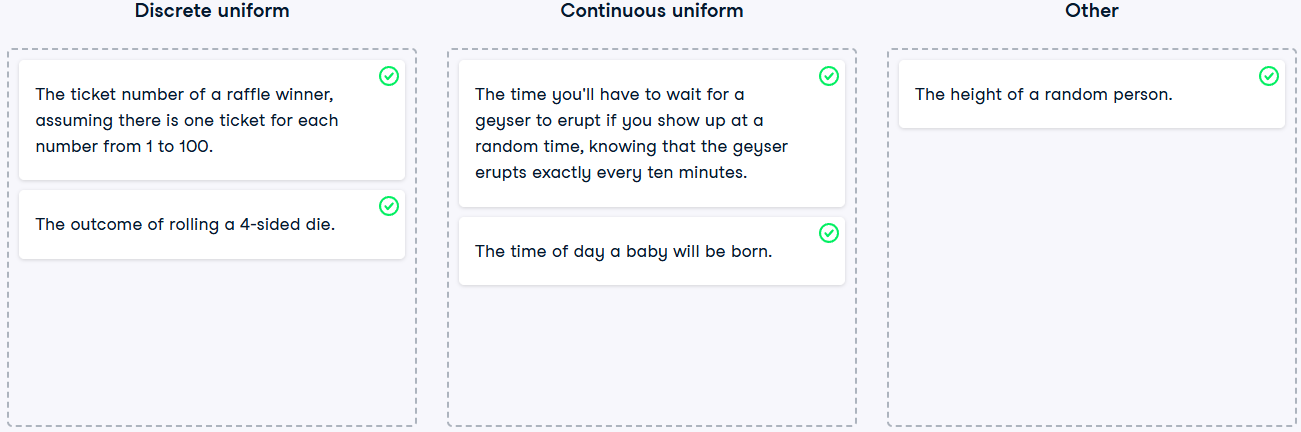

**Data back-ups**   
The sales software used at your company is set to automatically back itself up, but no one knows exactly what time the back-ups happen. It is known, however, that back-ups happen exactly every 30 minutes. Amir comes back from sales meetings at random times to update the data on the client he just met with. He wants to know how long he'll have to wait for his newly-entered data to get backed up. Use your new knowledge of continuous uniform distributions to model this situation and answer Amir's questions.

In [10]:
# Min and max wait times for back-up that happens every 30 min
min_time = 0
max_time = 30

# Import uniform from scipy.stats
from scipy.stats import uniform

# Calculate probability of waiting less than 5 mins
prob_less_than_5 = uniform.cdf(5, min_time, max_time)
print(prob_less_than_5)

0.16666666666666666


In [11]:
# Min and max wait times for back-up that happens every 30 min
min_time = 0
max_time = 30

# Import uniform from scipy.stats
from scipy.stats import uniform

# Calculate probability of waiting more than 5 mins
prob_greater_than_5 = 1- uniform.cdf(5, min_time, max_time)
print(prob_greater_than_5)

0.8333333333333334


In [12]:
# Min and max wait times for back-up that happens every 30 min
min_time = 0
max_time = 30

# Import uniform from scipy.stats
from scipy.stats import uniform

# Calculate probability of waiting 10-20 mins
prob_between_10_and_20 = uniform.cdf(20, min_time, max_time)- uniform.cdf(10, min_time, max_time)
print(prob_between_10_and_20)

# wait-time calculations! There's a 33% chance that Amir will wait 10-20 minutes. In the next exercise,
# you'll make sure this calculation holds up by simulating some wait times.



0.3333333333333333


***Simulating wait times***  
To give Amir a better idea of how long he'll have to wait, you'll simulate Amir waiting 1000 times and create a histogram to show him what he should expect. Recall from the last exercise that his minimum wait time is 0 minutes and his maximum wait time is 30 minutes.

As usual, pandas as pd, numpy as np, and matplotlib.pyplot as plt are loaded.

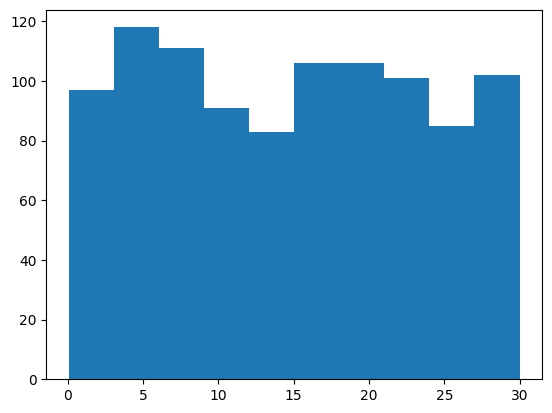

In [13]:
# Set random seed to 334
np.random.seed(334)

# Import uniform
from scipy.stats import uniform

# Generate 1000 wait times between 0 and 30 mins
wait_times = uniform.rvs(0, 30, size=1000)

# Create a histogram of simulated times and show plot
plt.hist(wait_times)
plt.show()

# Superb simulating! Unless Amir figures out exactly what time each backup happens,
# he won't be able to time his data entry so it gets backed up sooner, but it looks like he'll wait about 15 minutes on average.

-----

### The binomial distribution

S**imulating sales deals**  
Assume that Amir usually works on 3 deals per week, and overall, he wins 30% of deals he works on. Each deal has a binary outcome: it's either lost, or won, so you can model his sales deals with a binomial distribution. In this exercise, you'll help Amir simulate a year's worth of his deals so he can better understand his performance.

numpy is imported as np.

In [14]:
# Import binom from scipy.stats
from scipy.stats import binom

# Set random seed to 10
np.random.seed(10)

# Simulate 52 weeks of 3 deals
deals = binom.rvs(3, 0.3, size=52)

# Print mean deals won per week
print(np.mean(deals))

# Brilliant binomial simulation! In this simulated year, Amir won 0.83 deals on average each week.

0.8269230769230769


**Calculating binomial probabilities**  
Just as in the last exercise, assume that Amir wins 30% of deals. He wants to get an idea of how likely he is to close a certain number of deals each week. In this exercise, you'll calculate what the chances are of him closing different numbers of deals using the binomial distribution.

binom is imported from scipy.stats.

In [15]:
# Probability of closing 3 out of 3 deals
prob_3 = binom.pmf(3, 3, 0.3)

print(prob_3)

0.026999999999999996


In [16]:
# Probability of closing <= 1 deal out of 3 deals
prob_less_than_or_equal_1 = binom.cdf(1, 3, 0.3)

print(prob_less_than_or_equal_1)

0.784


In [17]:
# Probability of closing > 1 deal out of 3 deals
prob_greater_than_1 = 1 - binom.cdf(1, 3, 0.3)

print(prob_greater_than_1)

# Powerful probability calculations! Amir has about a 22% chance of closing more than one deal in a week.

0.21599999999999997


**How many sales will be won?**  
Now Amir wants to know how many deals he can expect to close each week if his win rate changes. Luckily, you can use your binomial distribution knowledge to help him calculate the expected value in different situations. Recall from the video that the expected value of a binomial distribution can be calculated by
. n * p

In [18]:
# Expected number won with 30% win rate
won_30pct = 3 * 0.3
print(won_30pct)

# Expected number won with 25% win rate
won_25pct = 3 * 0.25
print(won_25pct)

# Expected number won with 35% win rate
won_35pct = 3 * 0.35
print(won_35pct)

# Excellent expectation experimentation! If Amir's win rate goes up by 5%, he can expect to close more than 1 deal on average each week

0.8999999999999999
0.75
1.0499999999999998
